In [14]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix

In [32]:
recordings = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/*/recordings.csv")
recordings = glob.glob("../results/benchmark_sentence_similarities_only/recordings.csv")
recordings = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/benchmark_sentence_similarities_only/paragraph_and_sentence_len_6_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx/recordings.csv")
recordings = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/benchmark_sentence_similarities_only/min_len_0/*/recordings.csv")
recordings = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1/recordings.csv")
recordings = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2/recordings.csv")
recordings = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_*/recordings.csv")
#recordings.remove('/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/test/recordings.csv')

In [34]:
recordings = ['/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1/recordings.csv',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2/recordings.csv',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3/recordings.csv']
recordings

['/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1/recordings.csv',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2/recordings.csv',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3/recordings.csv']

In [35]:
path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/"

In [36]:
alphabet = "ABCDEFGHIJKLMNOPQRSTUVW"

In [37]:
def get_level_1_nace(x):
    x = float(x)
    
    if 1 <= x <= 3.21:
        return 'A'
    elif 5 <= x <= 9.9:
        return 'B'
    elif 10 <= x <= 33.20:
        return 'C'
    elif 35 <= x <= 35.30:
        return 'D'
    elif 36 <= x <= 39:
        return 'E' 
    elif 41 <= x <= 43.99:
        return 'F'
    elif 45 <= x <= 47.99:
        return 'G'
    elif 49 <= x <= 53.2:
        return 'H'
    elif 55 <= x <= 56.3:
        return 'I'
    elif 58 <= x <= 63.99:
        return 'J'
    elif 64 <= x <= 66.3:
        return 'K'
    elif 68 <= x <= 68.32:
        return 'L'
    elif 69 <= x <= 75:
        return 'M' 
    elif 77 <= x <= 82.99:
        return 'N'
    elif 84 <= x <= 84.3:
        return 'O'
    elif 85 <= x <= 85.6:
        return 'P'
    elif 86 <= x <= 88.99:
        return 'Q'
    elif 90 <= x <= 93.29:
        return 'R'
    elif 94 <= x <= 96.09:
        return 'S' 
    elif 97 <= x <= 98.2:
        return 'T'
    elif x == 99:
        return 'U'
    else:
        return None

def get_all_level(nace_code, df_nace_codes_descriptions= None): 

    if nace_code < 10:
        nace_code = "0" + str(nace_code)

    init_level = None 

    if nace_code.isalpha(): 
        init_level = 1
    elif "." not in nace_code: 
        init_level = 2
    else: 
        init_level = len(nace_code.split(".")[1])+2

    levels = {init_level: nace_code}

    for level in range(1,init_level):     
        print(level)
        if level == 2: 
            levels[level] = nace_code[:2]
        if level == 1: 
            levels[level] = get_level_1_nace(float(nace_code))

In [38]:
df_nace_codes_descriptions = pd.read_csv("../data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv", sep="\t")
df_nace_codes_descriptions

,ORDER_KEY,ID,CODE,NAME,PARENT_ID,LEVEL,Includes,IncludesAlso,Excludes
0,200,A,A,"AGRICULTURE, FORESTRY AND FISHING",NaN,1,This section includes the exploitation of vege...,NaN,NaN
1,300,1,1,"Crop and animal production, hunting and relate...",A,2,"This division includes two basic activities, n...",This division also includes service activities...,Agricultural activities exclude any subsequent...
2,350,11,01.1,Growing of non-perennial crops,1,3,This group includes the growing of non-perenni...,NaN,NaN
3,355,111,01.11,"Growing of cereals (except rice), leguminous c...",11,4,This class includes all forms of growing of ce...,NaN,"This class excludes:\n- growing of rice, see 0..."
4,360,112,01.12,Growing of rice,11,4,This class includes:\n- growing of rice (inclu...,NaN,NaN
...,...,...,...,...,...,...,...,...,...
991,51295,9820,98.20,Undifferentiated service-producing activities ...,982,4,This class includes the undifferentiated subsi...,NaN,NaN
992,51495,U,U,ACTIVITIES OF EXTRATERRITORIAL ORGANISATIONS A...,NaN,1,This class includes:\n- activities of internat...,NaN,NaN
993,51595,99,99,Activities of extraterritorial organisations a...,U,2,NaN,NaN,NaN
994,51645,990,99.0,Activities of extraterritorial organisations a...,99,3,NaN,NaN,NaN


# Numerics

### Eine recordings auswerten

In [39]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

In [40]:
for recording in sorted(recordings): 
    print("\nSentence Len :" + recording.split("sentence_len")[1][1] + ", Nace Level: " + recording.split("nace_level")[1][1])
    df = pd.read_csv(recording)
    for i in range(1,5): 
        if f"position_lvl_{i}" in df.columns: 
            print(f"Mean Position Level {i}: ", round(df[f"position_lvl_{i}"].mean(), 2), " from ", df.loc[0,f"classes_lvl_{i}"], " classes.")
            #y_true = df["NACE"].apply(lambda x: get_all_level(x)[1])
            y_pred = df[f"position_lvl_{i}"]
            y_true = np.zeros(shape=len(y_pred))
            
            print(f"Metrics for Level {i}:")
            #print("  Precision:", precision_score(y_true, y_pred))
            #print("  Recall:", recall_score(y_true, y_pred))
            print("  Accuracy:", accuracy_score(y_true, y_pred))
            #print("  F1 Score:", f1_score(y_true, y_pred))
            print("  Mean Reciprocal Rank:", mean_reciprocal_rank(df[f"position_lvl_{i}"]))


Sentence Len :6, Nace Level: 1
Mean Position Level 1:  4.91  from  21  classes.
Metrics for Level 1:
  Accuracy: 0.16720257234726688
  Mean Reciprocal Rank: 0.3793919231197361

Sentence Len :6, Nace Level: 2
Mean Position Level 1:  5.94  from  21  classes.
Metrics for Level 1:
  Accuracy: 0.16463022508038586
  Mean Reciprocal Rank: 0.3386020288107085
Mean Position Level 2:  24.22  from  88  classes.
Metrics for Level 2:
  Accuracy: 0.03408360128617363
  Mean Reciprocal Rank: 0.1507809732842655

Sentence Len :6, Nace Level: 3


FileNotFoundError: [Errno 2] No such file or directory: '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3/recordings.csv'

In [13]:
df[f"position_lvl_{2}"]

0        7.0
1       38.0
2        4.0
3       13.0
4        5.0
        ... 
1548    15.0
1549     5.0
1550     4.0
1551     NaN
1552    79.0
Name: position_lvl_2, Length: 1553, dtype: float64

In [27]:
# Initialize a dictionary to store the mean position levels for each recording
mean_positions = {"Recording": [], "Mean Top k% Level 1": [], "Mean Top k% Level 2": [], "Mean Top k% Level 3": [], "Mean Top k% Level 4": []}

# Iterate through each recording and calculate the mean position levels
for recording in sorted(recordings): 
    df = pd.read_csv(path + recording)
    mean_positions["Recording"].append("\nSentence Len :" + recording.split("sentence_len")[1][1] + ", Nace Level: " + recording.split("nace_level")[1][1])
    for i in range(1, 5): 
        if f"position_lvl_{i}" in df.columns: 
            mean_positions[f"Mean Top k% Level {i}"].append(round(df[f"position_lvl_{i}"].mean()/df.loc[0,f"classes_lvl_{i}"], 2))
        else:
            mean_positions[f"Mean Top k% Level {i}"].append(None)


# Convert the dictionary to a DataFrame for better visualization
mean_positions_df = pd.DataFrame(mean_positions)
mean_positions_df


FileNotFoundError: [Errno 2] No such file or directory: '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3//Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/benchmark_sentence_similarities_only/min_len_0/paragraph_and_sentence_len_3_min_chunk_len_0_cos_thresh_0.4_nace_level_1_stoxx/recordings.csv'

In [28]:
# Initialize a dictionary to store the mean position levels for each recording
mean_positions = {"Recording": [], "Mean (Class in Top 5%) Level 1": [], "Mean (Class in Top 5%) Level 2": [], "Mean (Class in Top 5%) Level 3": [], "Mean (Class in Top 5%) Level 4": []}

# Iterate through each recording and calculate the mean position levels
for recording in sorted(recordings): 
    df = pd.read_csv(path + recording)
    mean_positions["Recording"].append("\nSentence Len :" + recording.split("sentence_len")[1][1] + ", Nace Level: " + recording.split("nace_level")[1][1])
    for i in range(1, 5): 
        if f"position_lvl_{i}" in df.columns: 
            df["in_top_5"] = df[f"position_lvl_{i}"] <= df.loc[0,f"classes_lvl_{i}"] * 0.05
            mean_positions[f"Mean (Class in Top 5%) Level {i}"].append(round(df["in_top_5"].mean(), 2))
        else:
            mean_positions[f"Mean (Class in Top 5%) Level {i}"].append(None)

# Convert the dictionary to a DataFrame for better visualization
mean_positions_df = pd.DataFrame(mean_positions)
mean_positions_df


FileNotFoundError: [Errno 2] No such file or directory: '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3//Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/benchmark_sentence_similarities_only/min_len_0/paragraph_and_sentence_len_3_min_chunk_len_0_cos_thresh_0.4_nace_level_1_stoxx/recordings.csv'

# Position Distribution

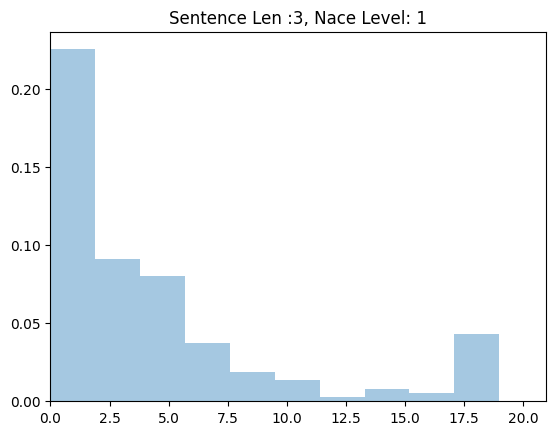

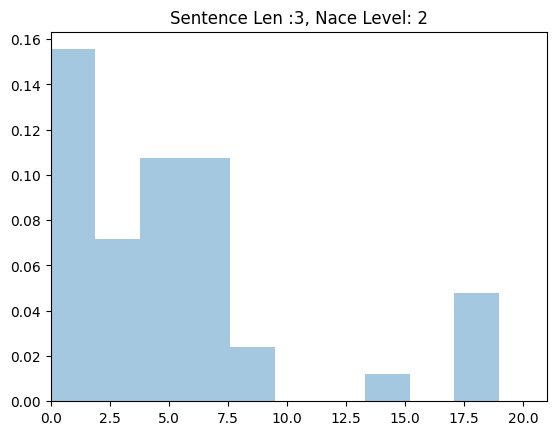

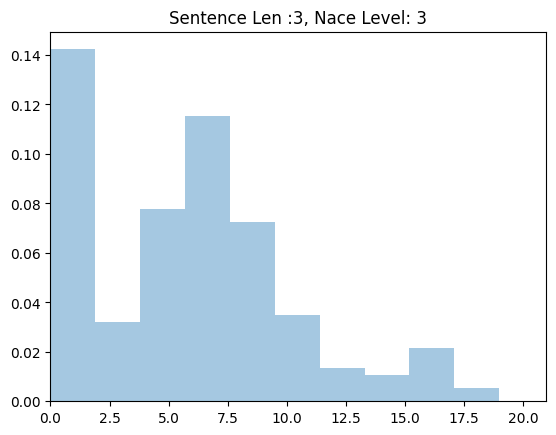

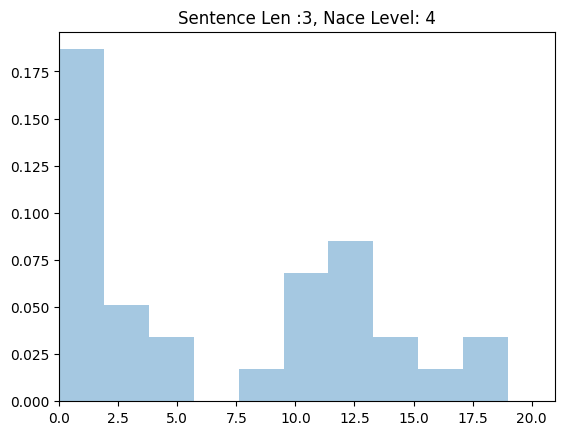

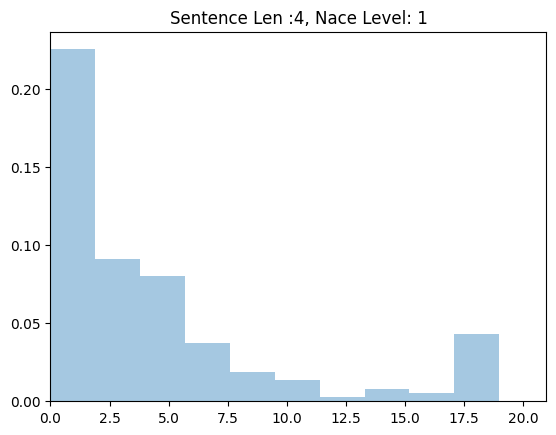

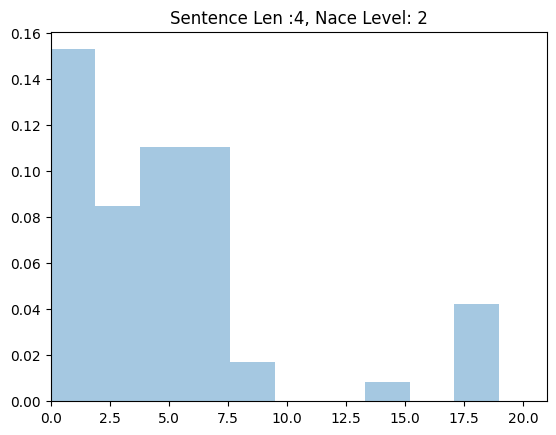

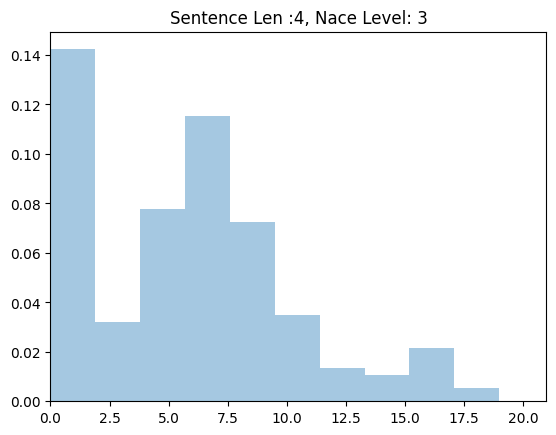

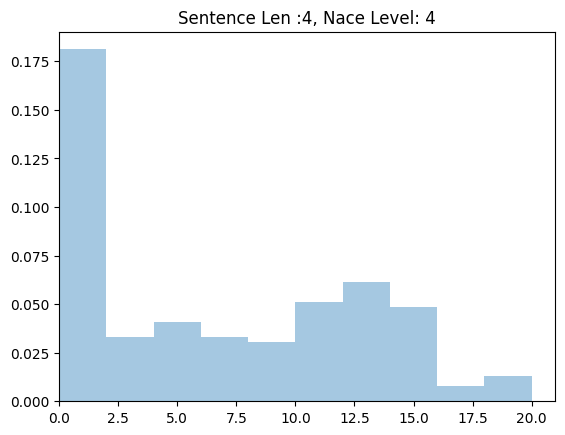

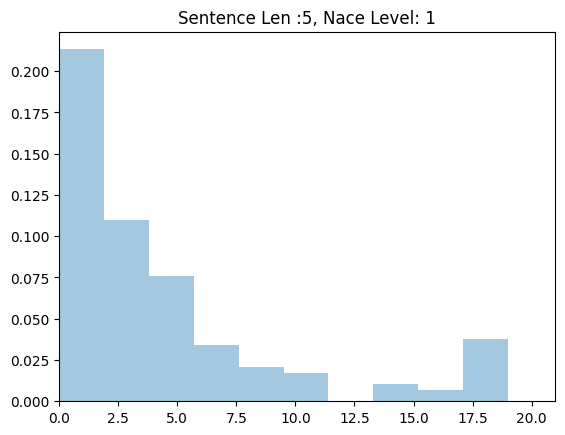

In [ ]:
for recording in sorted(recordings): 
    df = pd.read_csv(recording)
    df = df.dropna(subset="position_lvl_1")
    plt.hist(df["position_lvl_1"], alpha = 0.4, density=True)
    plt.xlim([0,21])
    plt.title("Sentence Len :" + recording.split("sentence_len")[1][1] + ", Nace Level: " + recording.split("nace_level")[1][1])
    plt.show()

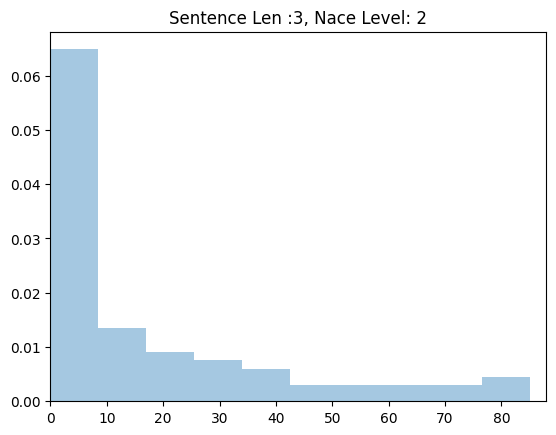

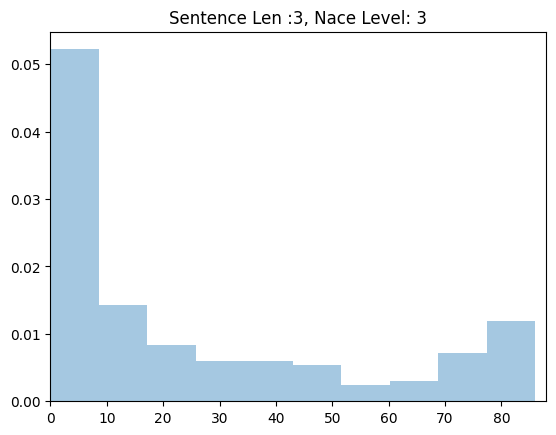

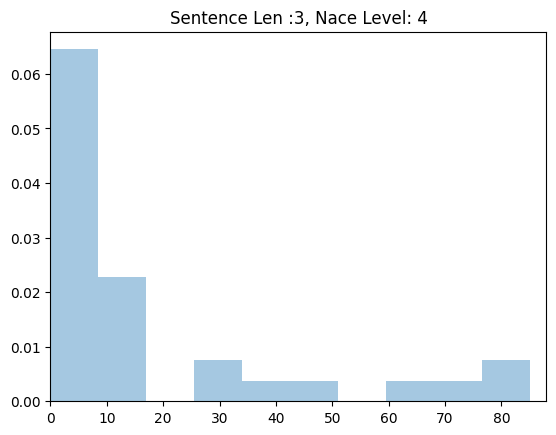

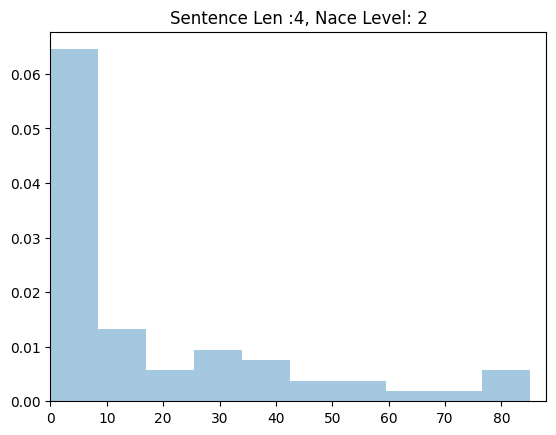

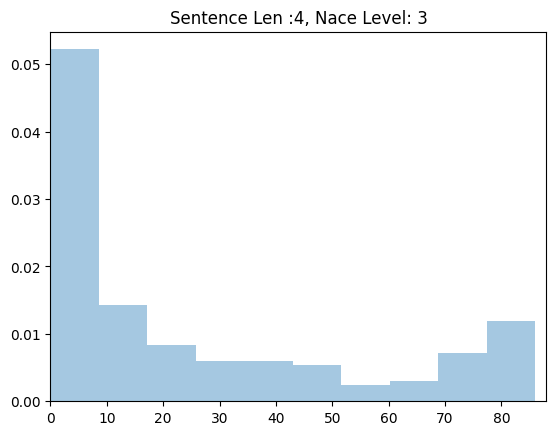

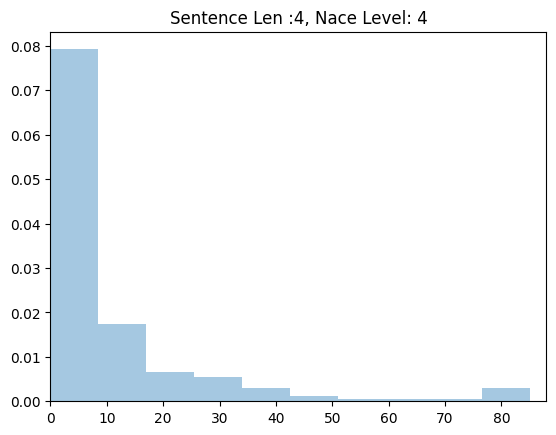

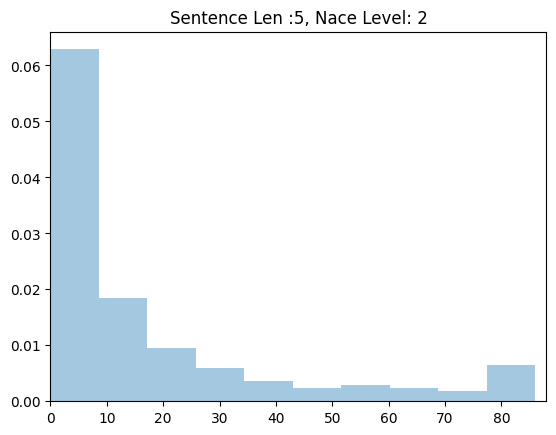

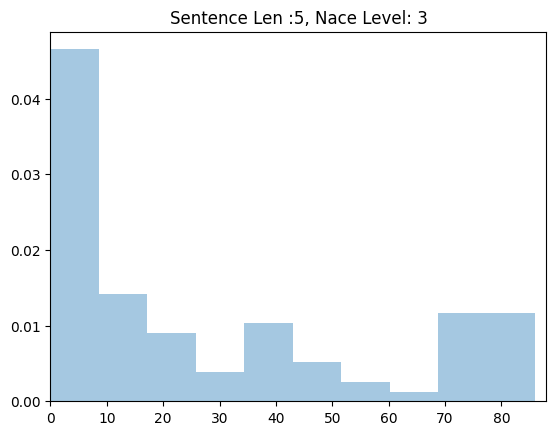

In [ ]:
for recording in sorted(recordings): 
    df = pd.read_csv(recording)
    if not "position_lvl_2" in df.columns: 
        continue
    df = df.dropna(subset="position_lvl_2")
    plt.hist(df["position_lvl_2"], alpha = 0.4, density=True)
    plt.xlim([0,88])
    plt.title("Sentence Len :" + recording.split("sentence_len")[1][1] + ", Nace Level: " + recording.split("nace_level")[1][1])
    plt.show()

# Confusionmatrix

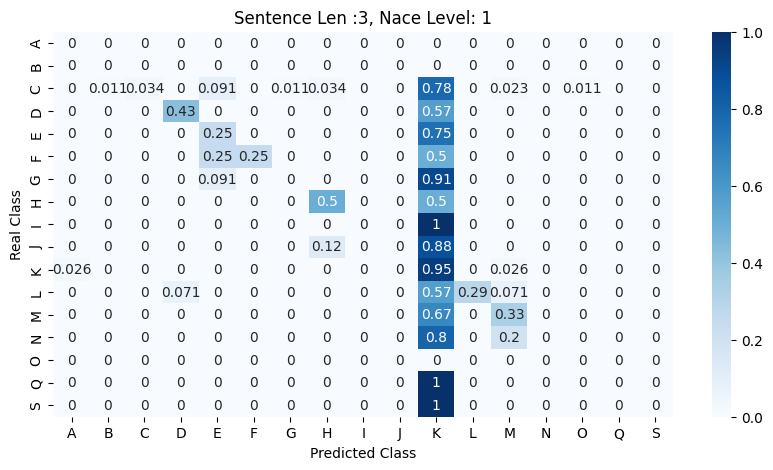

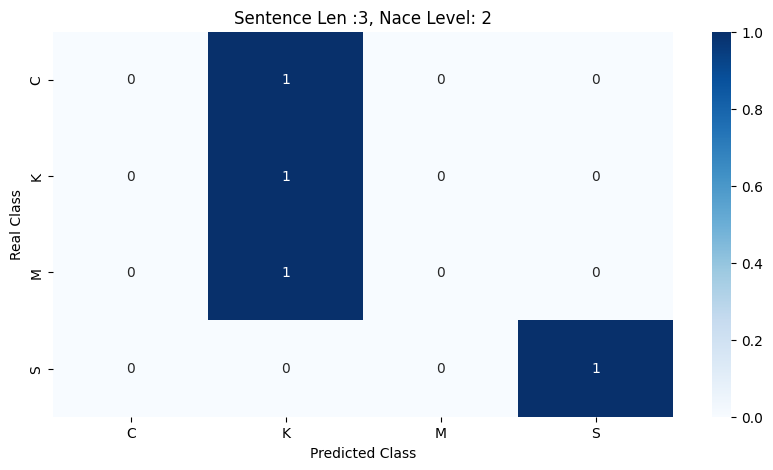

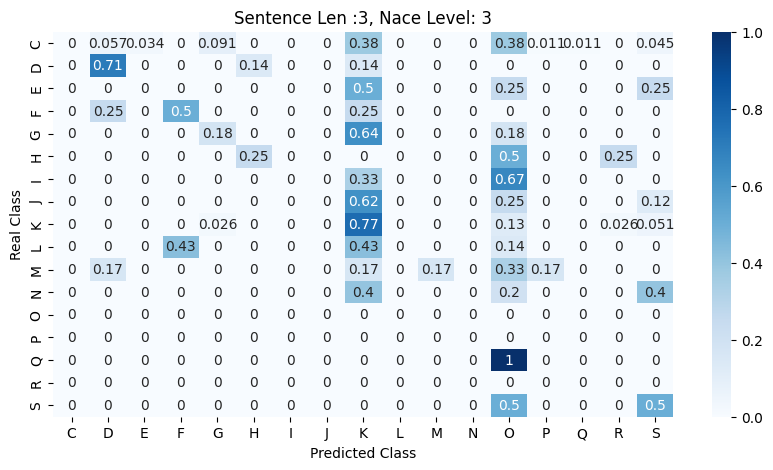

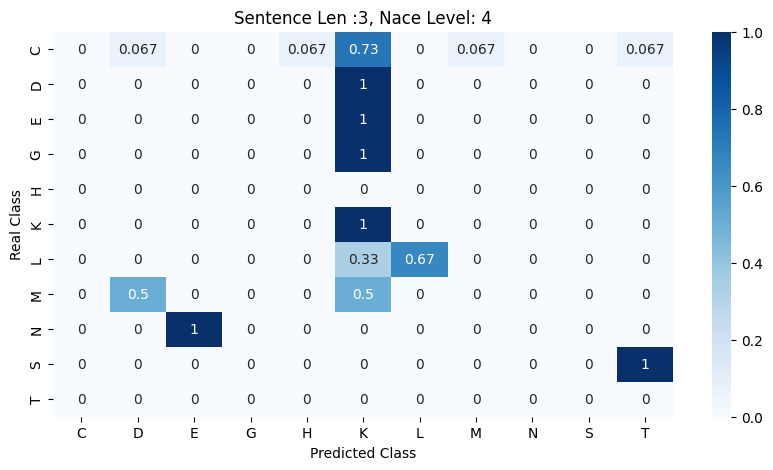

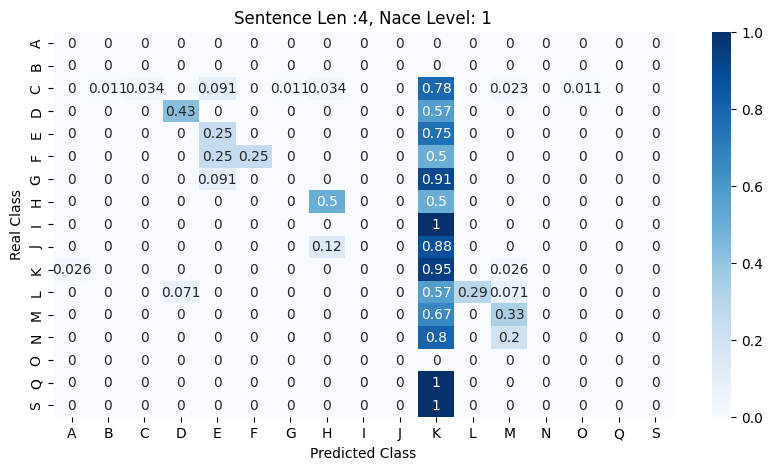

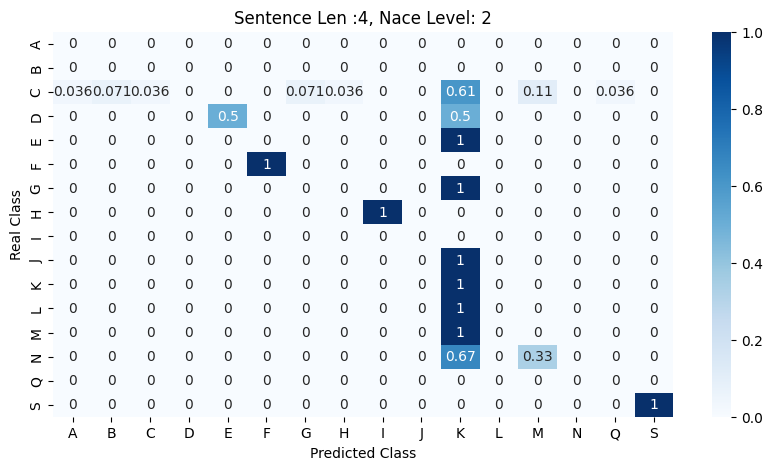

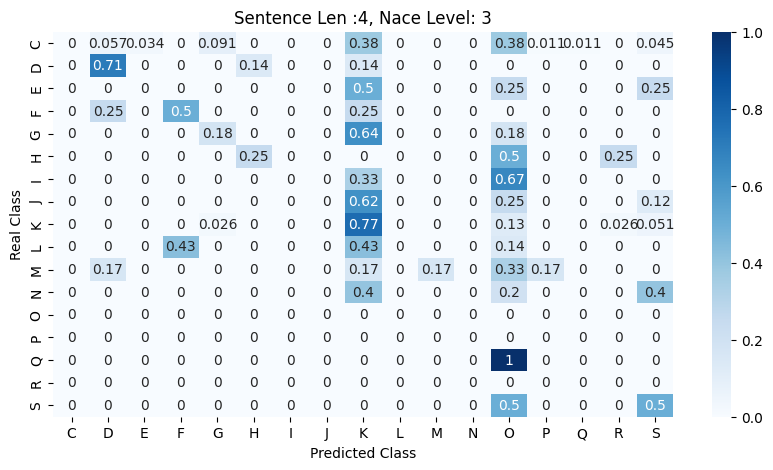

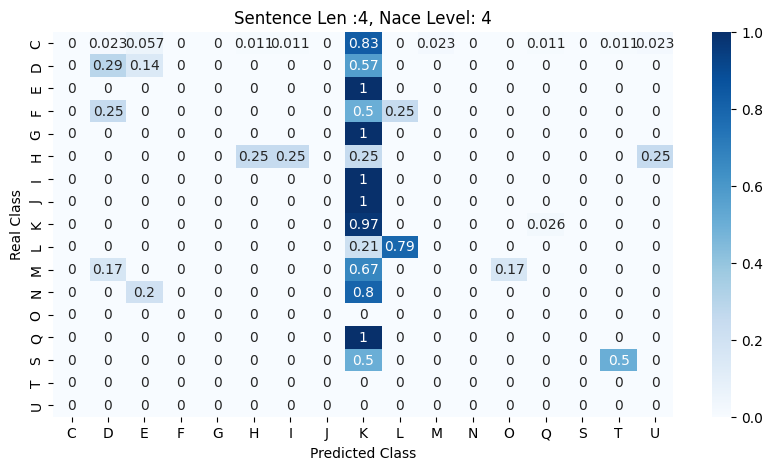

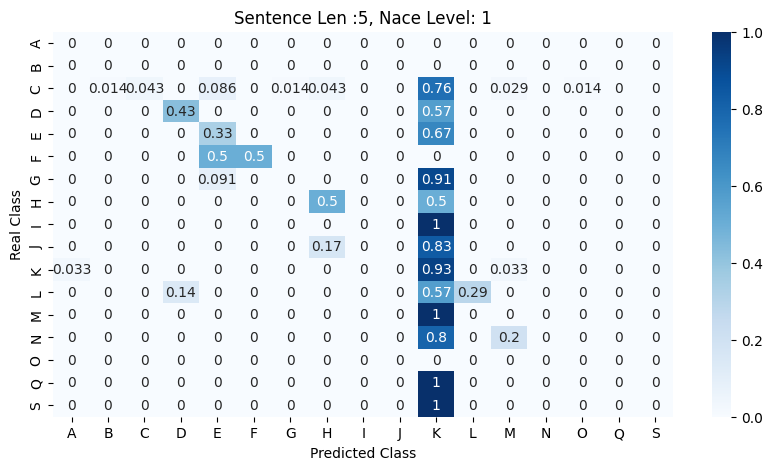

In [ ]:
for recording in sorted(recordings): 
    df = pd.read_csv(recording)
    df = df.dropna(subset="position_lvl_1")
    df["NACE_LVL_1"] = df["NACE"].apply(lambda x: get_all_level(x)[1])
    df["first_class_classification_lvl_1"] = df["classification_lvl_1"].apply(lambda x: x[2])
    
    # Beispiel: wahre und vorhergesagte Labels
    y_true = df["NACE_LVL_1"]
    y_pred = df["first_class_classification_lvl_1"]

    # Konfusionsmatrix berechnenzzzzz
    labels = np.unique(list(y_pred) + list(y_true))
    cm = confusion_matrix(y_true, y_pred, labels = labels, normalize='true')

    #Visualisieren
    plt.figure(figsize=(10,5))
    sns.heatmap(cm, annot=True, cmap="Blues",xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Real Class")
    plt.title("Sentence Len :" + recording.split("sentence_len")[1][1] + ", Nace Level: " + recording.split("nace_level")[1][1])
    plt.show()

# Visualize the position lvl 1

In [ ]:
# Test: is position in top 5? 
df = pd.read_csv("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/paragraph_and_sentence_len_4_min_chunk_len_100_cos_thresh_0.4_nace_level_3_stoxx/recordings.csv")
df = df.dropna(subset="position_lvl_1")
df["NACE_LVL_1"] = df["NACE"].apply(lambda x: get_all_level(x)[1])
df

In [ ]:
df = pd.read_csv(recordings[0])
df

,Unnamed: 0,name,NACE,label_description,position_lvl_1,classes_lvl_1,classification_lvl_1,position_lvl_2,classes_lvl_2,classification_lvl_2,position_lvl_3,classes_lvl_3,classification_lvl_3,position_lvl_4,classes_lvl_4,classification_lvl_4
0,0,Hannover Rueck SE1.txt,65.11,Life insurance,0.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.039...,0.0,88.0,"{'65_Insurance, reinsurance and pension fundin...",8.0,272.0,"{'65.2_Reinsurance': 0.07, '66.2_Activities au...",13.0,615.0,"{'66.21_Risk and damage evaluation': 0.099, '6..."
1,1,Interpump Group S.p.A.1.txt,28.12,Manufacture of fluid power equipment,9.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.021...,6.0,88.0,"{'64_Financial service activities, except insu...",15.0,272.0,{'64.2_Activities of holding companies': 0.078...,17.0,615.0,{'64.20_Activities of holding companies': 0.07...
2,2,Intertek Group PLC1.txt,71.20,Technical testing and analysis,1.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.022...,29.0,88.0,"{'64_Financial service activities, except insu...",37.0,272.0,{'64.2_Activities of holding companies': 0.063...,NaN,NaN,NaN
3,3,Anheuser-Busch InBev SANV3.txt,11.05,Manufacture of beer,13.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.018...,13.0,88.0,"{'64_Financial service activities, except insu...",38.0,272.0,{'64.2_Activities of holding companies': 0.048...,33.0,615.0,{'64.20_Activities of holding companies': 0.04...
4,4,Scout24 SE3.txt,96.09,Other personal service activities n.e.c.,2.0,21.0,{'T_ACTIVITIES OF HOUSEHOLDS AS EMPLOYERS; UND...,60.0,88.0,{'97_Activities of households as employers of ...,127.0,272.0,"{'94.1_Activities of business, employers and p...",226.0,615.0,{'94.12_Activities of professional membership ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,97,Swissquote Group Holding Ltd.1.txt,66.12,Security and commodity contracts brokerage,0.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.026...,2.0,88.0,{'70_Activities of head offices; management co...,5.0,272.0,"{'64.3_Trusts, funds and similar financial ent...",16.0,615.0,"{'64.30_Trusts, funds and similar financial en..."
98,98,Terna S.p.A.3.txt,35.11,Production of electricity,1.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.022...,2.0,88.0,"{'64_Financial service activities, except insu...",3.0,272.0,"{'64.3_Trusts, funds and similar financial ent...",3.0,615.0,"{'64.30_Trusts, funds and similar financial en..."
99,99,Gerresheimer AG1.txt,22.22,Manufacture of plastic packing goods,10.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.004...,8.0,88.0,{'21_Manufacture of basic pharmaceutical produ...,15.0,272.0,"{'64.3_Trusts, funds and similar financial ent...",14.0,615.0,"{'64.30_Trusts, funds and similar financial en..."
100,100,Airbus SE1.txt,30.30,Manufacture of air and spacecraft and related ...,9.0,21.0,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.006...,1.0,88.0,{'70_Activities of head offices; management co...,0.0,272.0,{'30.3_Manufacture of air and spacecraft and r...,NaN,NaN,NaN


In [ ]:
df = df.dropna(subset="NACE")

In [ ]:
df["NACE_LVL_1"] = df["NACE"].apply(lambda x: get_all_level(x)[1])
df["NACE_LVL_1"]

0      K
1      C
2      M
3      C
4      S
      ..
97     K
98     D
99     C
100    C
101    K
Name: NACE_LVL_1, Length: 102, dtype: object

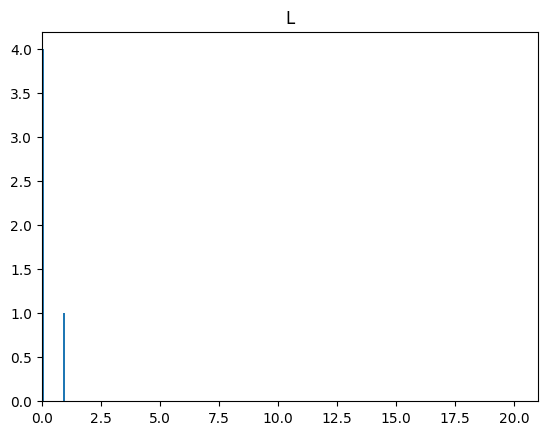

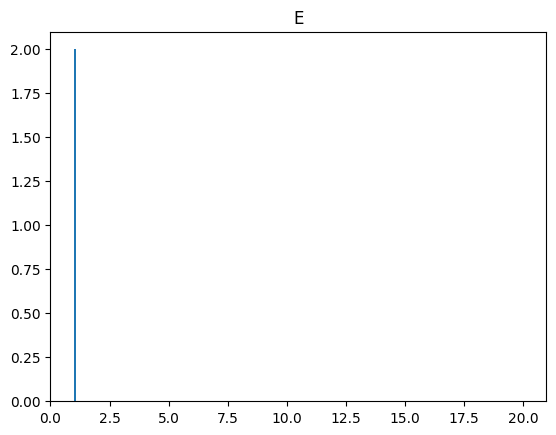

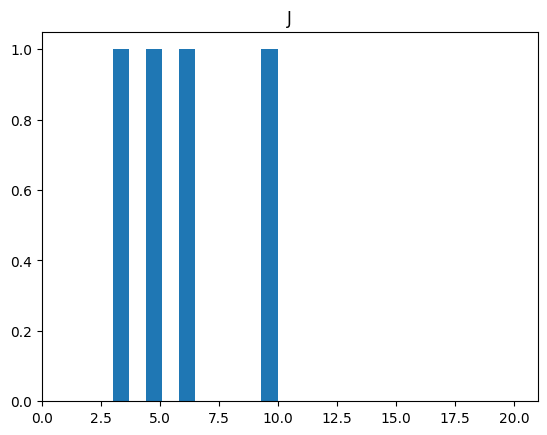

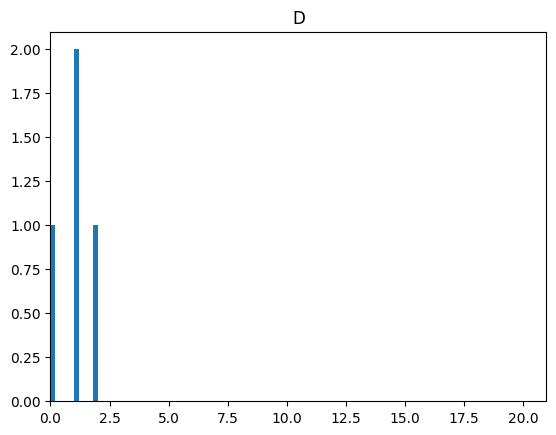

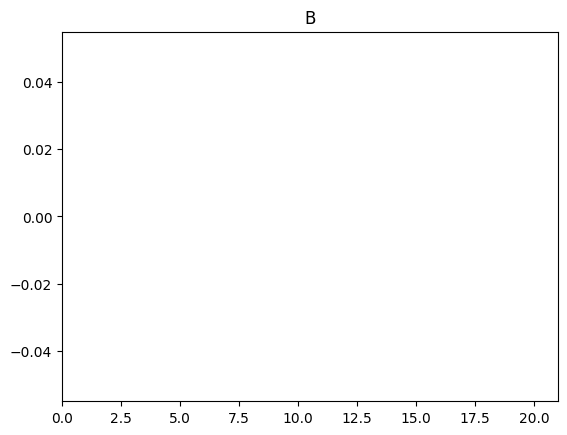

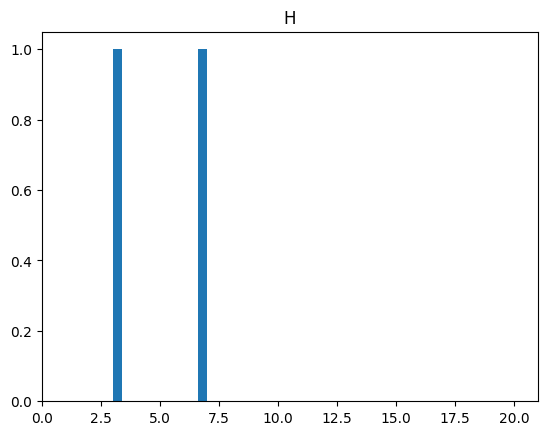

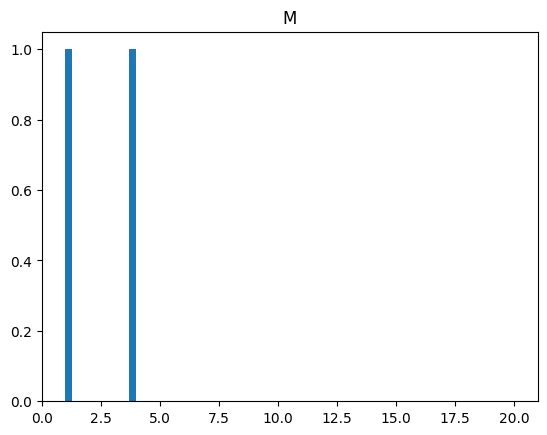

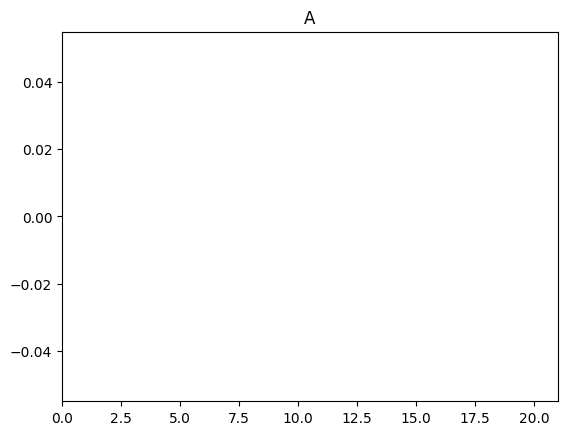

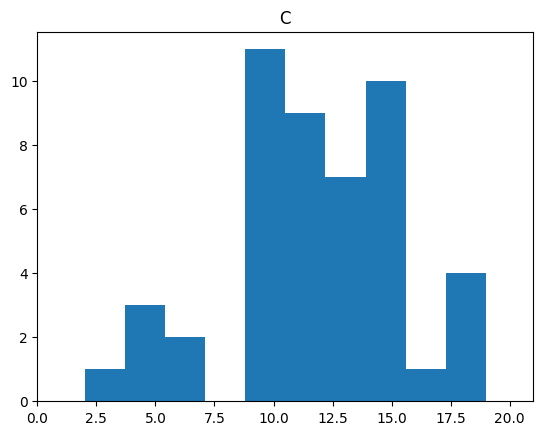

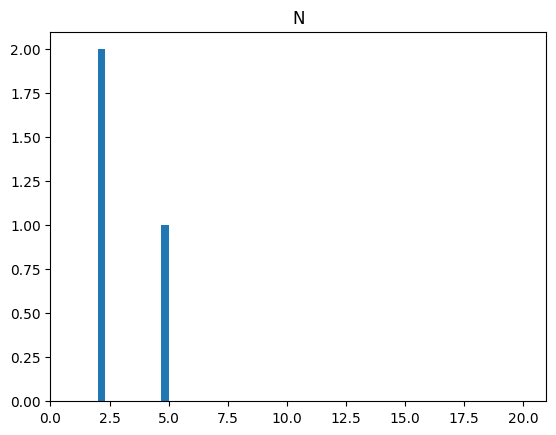

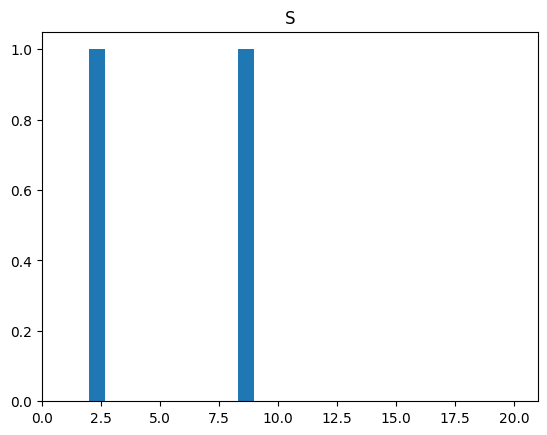

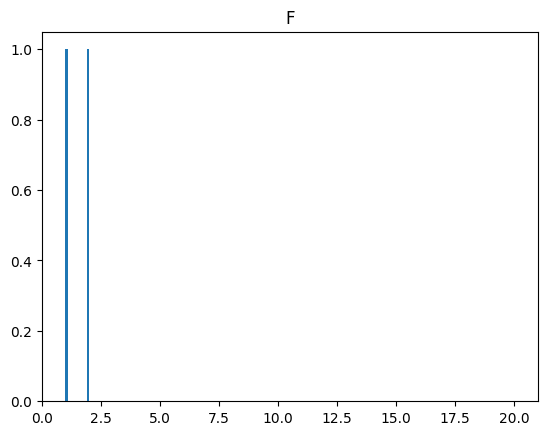

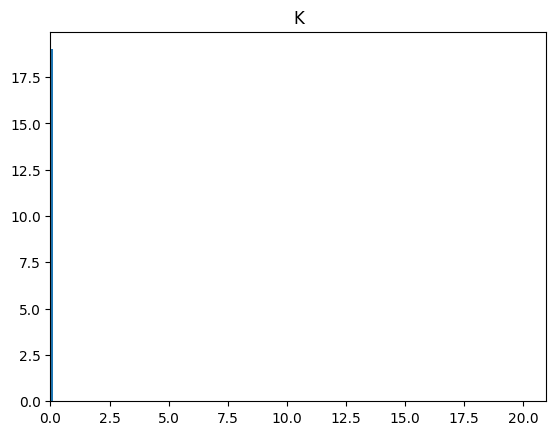

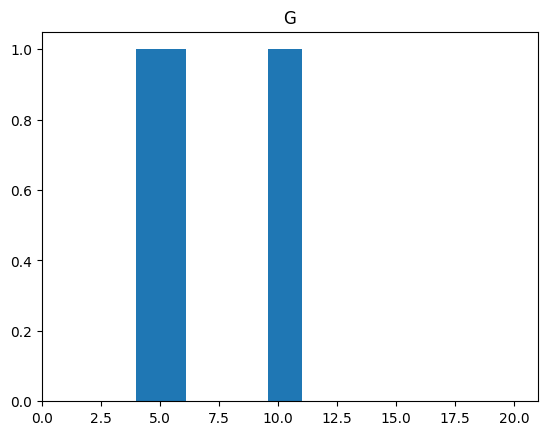

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


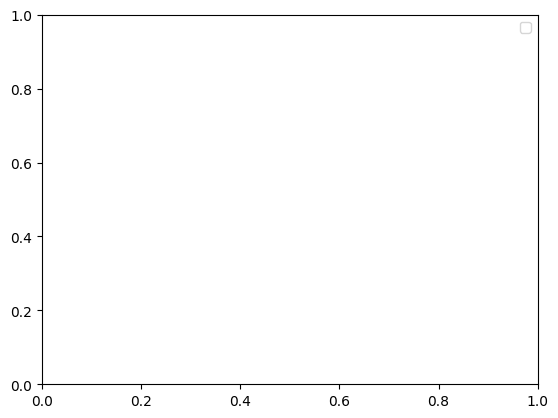

In [ ]:
for nace_class in set(df["NACE_LVL_1"]): 
    plt.hist(df[df["NACE_LVL_1"] == nace_class]["position_lvl_1"].dropna(), label=nace_class)
    plt.xlim(0,21)
    plt.title(nace_class)
    plt.show()

plt.legend()